# Bondview Module 1: Basic Workflow Examples

This notebook demonstrates the normal path from `Module1Calculator` to a completed
`Module1Result`, followed by result-only workflows in:

- `Module1Analysis`
- `Module1Diagnostics`
- `Module1HistoricalAnalysis`
- `Module1SensitivityDiagnostics`

## Import the Module 1 interfaces

`Module1Calculator` owns configuration loading, local input loading, horizon
resolution, and calculation. The other classes consume a completed
`Module1Result`.


In [1]:
from module1_calculator import Module1Calculator, Module1Result
from module1_analysis import Module1Analysis
from module1_diagnostics import Module1Diagnostics
from module1_historical_analysis import Module1HistoricalAnalysis
from module1_sensitivity_diagnostics import Module1SensitivityDiagnostics

In [8]:
import pandas as pd

## Run the Module 1 pipeline and create `Module1Result`

The constructor loads the selected configuration and local input files. The pipeline
then calculates features, component scores, component labels, and exposure stances.

`to_module1_result()` does not rerun the pipeline. It validates that the completed
outputs exist and returns an isolated snapshot.


In [2]:
series_config_path = "data/fred_series_config.csv"
module1_config_path = "data/module1_config.yaml"
data_path = "data/raw_data_19980101_20260508.csv"

In [3]:
calculator = Module1Calculator(
    series_config_path=series_config_path,
    module1_config_path=module1_config_path,
    data_path=data_path,
)

/tmp/ipykernel_12278/1482755625.py:1: RuntimeWarning: FRED_API_KEY is not set. Local data loading remains available, but FRED downloads will fail until the key is configured.
  calculator = Module1Calculator(


In [4]:
calculator.run_module1_pipeline()

,duration_rule_stance_score,duration_rule_stance,duration_rule_stance_strength,credit_stance_score,credit_stance,credit_stance_strength,usd_exposure_stance_score,usd_exposure_stance,usd_exposure_stance_strength,curve_positioning_score,curve_positioning,curve_positioning_strength
1998-01-01,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>
1998-01-02,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>
1998-01-05,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>
1998-01-06,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>
1998-01-07,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>,NaN,NaN,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-04,-0.7,duration_negative,moderate,-0.255267,credit_neutral,weak,0.590431,usd_positive,moderate,-0.75,short_end,moderate
2026-05-05,-0.7,duration_negative,moderate,-0.256200,credit_neutral,weak,0.586627,usd_positive,moderate,-0.75,short_end,moderate
2026-05-06,-0.7,duration_negative,moderate,-0.256800,credit_neutral,weak,0.543794,usd_positive,moderate,-0.75,short_end,moderate
2026-05-07,-0.7,duration_negative,moderate,-0.257533,credit_neutral,weak,0.506990,usd_positive,moderate,-0.75,short_end,moderate


In [5]:
result = calculator.to_module1_result()

In [6]:
result.horizons

{'rates': 126,
 'ultra_long_rates': 126,
 'duration_rate_shock': 20,
 'curve': 126,
 'long_end_curve': 126,
 'credit': 63,
 'fx': 63,
 'normalization': 252,
 'normalization_monthly': 36,
 'score_smoothing': 30,
 'score_smoothing_monthly': 3,
 'daily_macro_input_smoothing': 30,
 'inflation_yoy': 12,
 'inflation_change': 3,
 'policy_realized': 6}

### Inspect the main result tables

The result contains safe snapshots of the runtime tables and the exact parsed Module 1
configuration used for the run.


In [9]:
result_tables = {
    "data": result.data,
    "features": result.features,
    "scores": result.scores,
    "labels": result.labels,
    "stance_scores": result.stance_scores,
    "exposure_stance": result.exposure_stance,
}

table_inventory = pd.DataFrame(
    [
        {
            "table": name,
            "rows": None if table is None else len(table),
            "columns": None if table is None else len(table.columns),
            "first_date": None if table is None or table.empty else table.index.min(),
            "last_date": None if table is None or table.empty else table.index.max(),
        }
        for name, table in result_tables.items()
    ]
)

display(table_inventory)
display(result.exposure_stance.tail())

,table,rows,columns,first_date,last_date
0,data,7495,7,1998-01-01,2026-05-08
1,features,7495,16,1998-01-01,2026-05-08
2,scores,7495,10,1998-01-01,2026-05-08
3,labels,7495,10,1998-01-01,2026-05-08
4,stance_scores,7495,4,1998-01-01,2026-05-08
5,exposure_stance,7495,12,1998-01-01,2026-05-08


,duration_rule_stance_score,duration_rule_stance,duration_rule_stance_strength,credit_stance_score,credit_stance,credit_stance_strength,usd_exposure_stance_score,usd_exposure_stance,usd_exposure_stance_strength,curve_positioning_score,curve_positioning,curve_positioning_strength
2026-05-04,-0.7,duration_negative,moderate,-0.255267,credit_neutral,weak,0.590431,usd_positive,moderate,-0.75,short_end,moderate
2026-05-05,-0.7,duration_negative,moderate,-0.256200,credit_neutral,weak,0.586627,usd_positive,moderate,-0.75,short_end,moderate
2026-05-06,-0.7,duration_negative,moderate,-0.256800,credit_neutral,weak,0.543794,usd_positive,moderate,-0.75,short_end,moderate
2026-05-07,-0.7,duration_negative,moderate,-0.257533,credit_neutral,weak,0.506990,usd_positive,moderate,-0.75,short_end,moderate
2026-05-08,-0.7,duration_negative,moderate,-0.258067,credit_neutral,weak,0.472912,usd_neutral,weak,-0.75,short_end,moderate


In [10]:
validation_issues = result.module1_config_validation["issues"]
print("Configuration validation issues:", len(validation_issues))
display(validation_issues.head())

credit_config = result.module1_config["exposure_stances"]["credit"]
print(
    "Outer credit state_stabilization present:",
    "state_stabilization" in credit_config,
)
display(
    pd.DataFrame(
        credit_config["rule_mapped"]["state_stabilization"]
    ).T
)

Configuration validation issues: 0


,section,name,field,issue,detail


Outer credit state_stabilization present: False


,hysteresis_buffer,min_state_persistence
credit_spread_change,0.0,1.0
credit_spread_state,0.0,1.0


## Basic `Module1Analysis`

Analysis is result-only. It does not run or mutate the calculation pipeline.


In [11]:
analysis = Module1Analysis(result)

inspection = analysis.inspect_module1_results(n=5)
display(inspection["recent_combined_snapshot"])
print(
    "Latest complete exposure-stance date:",
    inspection["latest_complete_exposure_stance_date"],
)

,duration_preference_score,duration_rate_shock_score,credit_spread_change_score,credit_spread_state_score,inflation_pressure_score,policy_stance_score,fx_score,curve_change_score,curve_state_score,curve_move_driver_score,...,duration_rule_stance_strength,credit_stance_score,credit_stance,credit_stance_strength,usd_exposure_stance_score,usd_exposure_stance,usd_exposure_stance_strength,curve_positioning_score,curve_positioning,curve_positioning_strength
2026-05-04,-1.081295,-0.782940,-0.012473,-0.776333,0.364093,-0.807021,0.590431,-1.586620,0.016333,-1.0,...,moderate,-0.255267,credit_neutral,weak,0.590431,usd_positive,moderate,-0.75,short_end,moderate
2026-05-05,-1.122062,-0.554847,0.001734,-0.781000,0.364093,-0.807021,0.586627,-1.561543,0.016667,-1.0,...,moderate,-0.256200,credit_neutral,weak,0.586627,usd_positive,moderate,-0.75,short_end,moderate
2026-05-06,-1.133157,-0.335725,0.007745,-0.784000,0.364093,-0.807021,0.543794,-1.544628,0.016667,-1.0,...,moderate,-0.256800,credit_neutral,weak,0.543794,usd_positive,moderate,-0.75,short_end,moderate
2026-05-07,-1.147998,-0.600949,0.021133,-0.787667,0.364093,-0.807021,0.506990,-1.522809,0.017667,-1.0,...,moderate,-0.257533,credit_neutral,weak,0.506990,usd_positive,moderate,-0.75,short_end,moderate
2026-05-08,-1.151538,-0.303976,0.028217,-0.790333,0.364093,-0.807021,0.472912,-1.506451,0.015000,-1.0,...,moderate,-0.258067,credit_neutral,weak,0.472912,usd_neutral,weak,-0.75,short_end,moderate


Latest complete exposure-stance date: 2026-05-08 00:00:00


### Resolve a target and inspect its dependencies

Targets can be addressed by their configured names or supported aliases. Explicit
levels remove ambiguity.


In [12]:
credit_resolution = analysis.resolve_target("credit", level="stance")
credit_resolution.to_target_info()

{'level': 'stance',
 'target': 'credit',
 'canonical_target': 'credit',
 'source_layer': 'stance',
 'source_table': 'exposure_stance',
 'score_col': 'credit_stance_score',
 'label_col': 'credit_stance',
 'strength_col': 'credit_stance_strength',
 'config': {'description': 'Macro stance toward credit exposure.',
  'score_output': 'credit_stance_score',
  'stance_output': 'credit_stance',
  'strength_output': 'credit_stance_strength',
  'function': 'credit_spread_stance',
  'state_buckets': {'credit_spread_change': {'positive': 'positive',
    'neutral': 'neutral',
    'negative': 'negative'},
   'credit_spread_state': {'positive': 'wide',
    'neutral': 'normal',
    'negative': 'tight'}},
  'rule_scores': {'positive|wide': 1.2,
   'positive|normal': 1.0,
   'positive|tight': 0.4,
   'neutral|wide': 0.2,
   'neutral|normal': 0.0,
   'neutral|tight': -0.2,
   'negative|wide': -0.8,
   'negative|normal': -1.0,
   'negative|tight': -1.2},
  'rule_adjustments': {'default_cap': {'min': -1.5,

In [13]:
print(
    "Raw inputs used by credit stance:",
    analysis.raw_inputs_for_target("credit", level="stance"),
)

credit_context = analysis.get_target_context(
    target="credit",
    level="stance",
    dependency_level="full",
    include_labels=True,
    include_strength=True,
    start="2020-03-01",
    end="2020-04-30",
)

print("Returned column groups:")
display(pd.Series(credit_context.returned_columns, dtype="object"))
display(credit_context.data.head())

Raw inputs used by credit stance: ['baa10y']
Returned column groups:


target                                         (credit_stance_score,)
component_scores    (credit_spread_change_score, credit_spread_sta...
component_labels    (credit_spread_change_label, credit_spread_sta...
features                                (baa10y_change, baa10y_level)
raw_inputs                                                  (baa10y,)
labels              (credit_stance, credit_spread_change_label, cr...
strength                                    (credit_stance_strength,)
dtype: object

,credit_stance_score,credit_stance,credit_stance_strength,credit_spread_change_score,credit_spread_state_score,credit_spread_change_label,credit_spread_state_label,baa10y_change,baa10y_level,baa10y
2020-03-01,0.0,credit_neutral,weak,0.352216,-0.425000,credit_spread_stable,credit_spread_normal,NaN,NaN,2.38
2020-03-02,0.0,credit_neutral,weak,0.210740,-0.410333,credit_spread_stable,credit_spread_normal,0.37,2.44,2.44
2020-03-03,0.0,credit_neutral,weak,0.049459,-0.393667,credit_spread_stable,credit_spread_normal,0.43,2.48,2.48
2020-03-04,0.0,credit_neutral,weak,-0.116372,-0.377000,credit_spread_stable,credit_spread_normal,0.46,2.47,2.47
2020-03-05,0.0,credit_neutral,weak,-0.291878,-0.358667,credit_spread_stable,credit_spread_normal,0.48,2.52,2.52


### Build and plot a comparison dataset

For a stance target, `compare="components"` compares the stance score with its
component scores. Other supported comparison layers include `features`,
`raw_inputs`, and `full`.


Target columns: ('credit_stance_score',)
Comparison columns: ('credit_spread_change_score', 'credit_spread_state_score')


,credit_stance_score,credit_spread_change_score,credit_spread_state_score
2020-02-01,1.2,1.149217,-0.499667
2020-02-03,1.2,1.110790,-0.495667
2020-02-04,1.2,1.110790,-0.491333
2020-02-05,1.2,1.077974,-0.487667
2020-02-06,1.2,1.041753,-0.484667


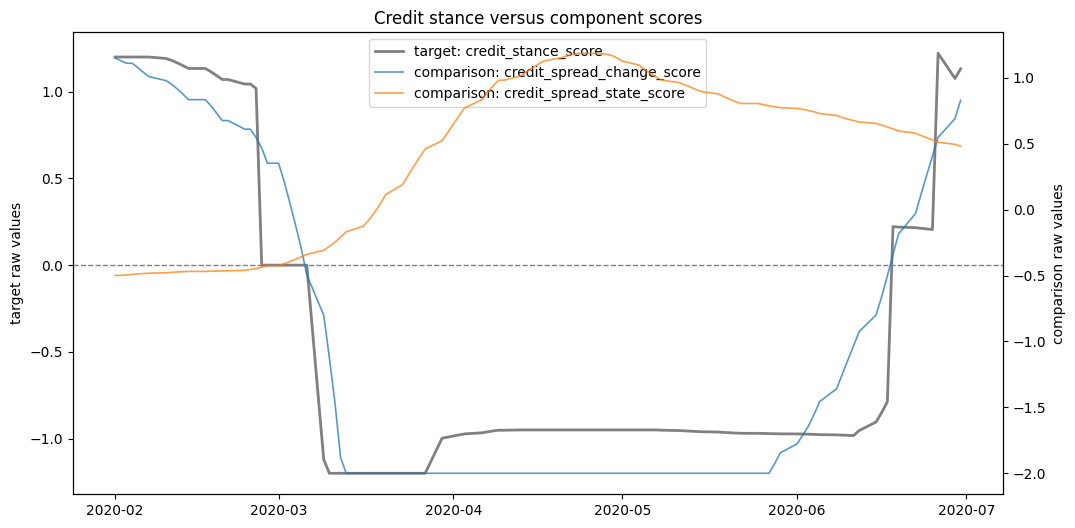

In [16]:
credit_comparison = analysis.build_target_comparison_dataset(
    target="credit",
    level="stance",
    compare="components",
    include_labels=False,
    include_strength=False,
    start="2020-02-01",
    end="2020-06-30",
)

print("Target columns:", credit_comparison.target_columns)
print("Comparison columns:", credit_comparison.comparison_columns)
display(credit_comparison.data.head())

_ = analysis.plot_target_comparison_dataset(
    credit_comparison,
    normalize=False,
    title="Credit stance versus component scores",
)

## 5. Basic `Module1Diagnostics`

Diagnostics explains completed results. It does not recalculate the normal production
pipeline.


In [17]:
diagnostics = Module1Diagnostics(result)

credit_trace = diagnostics.trace_stance_score(
    "credit",
    start="2020-03-01",
    end="2020-04-30",
    include_raw_input=True,
    include_labels=True,
)

display(credit_trace.head())
print("Trace columns:")
print(list(credit_trace.columns))

,credit_spread_change_score,credit_spread_state_score,credit_spread_change_state_raw,credit_spread_change_state,credit_spread_state_category_raw,credit_spread_state_category,state_stabilization_changed_change_state,state_stabilization_changed_spread_state,state_stabilization_changed_pair,credit_state_pair,...,rule_adjustment,credit_stance_score,credit_stance,credit_stance_strength,credit_spread_change_label,credit_spread_state_label,baa10y,baa10y_change,baa10y_change_prepared_for_credit_spread_change,baa10y_level_prepared_for_credit_spread_state
2020-03-01,0.352216,-0.425000,neutral,neutral,normal,normal,False,False,False,neutral|normal,...,0.0,0.0,credit_neutral,weak,credit_spread_stable,credit_spread_normal,2.38,NaN,NaN,NaN
2020-03-02,0.210740,-0.410333,neutral,neutral,normal,normal,False,False,False,neutral|normal,...,0.0,0.0,credit_neutral,weak,credit_spread_stable,credit_spread_normal,2.44,0.37,-0.061000,2.089667
2020-03-03,0.049459,-0.393667,neutral,neutral,normal,normal,False,False,False,neutral|normal,...,0.0,0.0,credit_neutral,weak,credit_spread_stable,credit_spread_normal,2.48,0.43,-0.039333,2.106333
2020-03-04,-0.116372,-0.377000,neutral,neutral,normal,normal,False,False,False,neutral|normal,...,0.0,0.0,credit_neutral,weak,credit_spread_stable,credit_spread_normal,2.47,0.46,-0.018000,2.123000
2020-03-05,-0.291878,-0.358667,neutral,neutral,normal,normal,False,False,False,neutral|normal,...,0.0,0.0,credit_neutral,weak,credit_spread_stable,credit_spread_normal,2.52,0.48,0.003667,2.141333


Trace columns:
['credit_spread_change_score', 'credit_spread_state_score', 'credit_spread_change_state_raw', 'credit_spread_change_state', 'credit_spread_state_category_raw', 'credit_spread_state_category', 'state_stabilization_changed_change_state', 'state_stabilization_changed_spread_state', 'state_stabilization_changed_pair', 'credit_state_pair', 'base_rule_score', 'credit_spread_change_intensity', 'credit_spread_state_intensity', 'rule_adjustment', 'credit_stance_score', 'credit_stance', 'credit_stance_strength', 'credit_spread_change_label', 'credit_spread_state_label', 'baa10y', 'baa10y_change', 'baa10y_change_prepared_for_credit_spread_change', 'baa10y_level_prepared_for_credit_spread_state']


### Rule-mapped state, transition, and stability views

`credit`, `curve_positioning`, and other rule-mapped stances can be inspected through
the unified diagnostic entry point.


In [18]:
credit_state = diagnostics.diagnose_rule_mapped_stance(
    "credit",
    start="2020-03-01",
    end="2020-04-30",
    view="state",
)
credit_transitions = diagnostics.diagnose_rule_mapped_stance(
    "credit",
    start="2020-03-01",
    end="2020-04-30",
    view="transitions",
)
credit_stability = diagnostics.diagnose_rule_mapped_stance(
    "credit",
    start="2020-03-01",
    end="2020-04-30",
    view="stability",
)

display(credit_state.head())
display(credit_transitions.head())
print("Stability tables:", list(credit_stability))
for name, table in credit_stability.items():
    print(f"\n{name}")
    display(table)

,credit_spread_change_score,credit_spread_state_score,credit_spread_change_state_raw,credit_spread_state_category_raw,credit_spread_change_state,credit_spread_state_category,state_stabilization_changed_change_state,state_stabilization_changed_spread_state,state_stabilization_changed_pair,credit_state_pair,base_rule_score,rule_adjustment,credit_stance_score,credit_spread_change_intensity,credit_spread_state_intensity,credit_stance,credit_stance_strength
2020-03-01,0.352216,-0.425000,neutral,normal,neutral,normal,False,False,False,neutral|normal,0.0,0.0,0.0,0.0,0.0,credit_neutral,weak
2020-03-02,0.210740,-0.410333,neutral,normal,neutral,normal,False,False,False,neutral|normal,0.0,0.0,0.0,0.0,0.0,credit_neutral,weak
2020-03-03,0.049459,-0.393667,neutral,normal,neutral,normal,False,False,False,neutral|normal,0.0,0.0,0.0,0.0,0.0,credit_neutral,weak
2020-03-04,-0.116372,-0.377000,neutral,normal,neutral,normal,False,False,False,neutral|normal,0.0,0.0,0.0,0.0,0.0,credit_neutral,weak
2020-03-05,-0.291878,-0.358667,neutral,normal,neutral,normal,False,False,False,neutral|normal,0.0,0.0,0.0,0.0,0.0,credit_neutral,weak


,date,credit_spread_change_state_raw,credit_spread_change_state,credit_spread_state_category_raw,credit_spread_state_category,credit_state_pair,previous_credit_state_pair,credit_state_pair_changed,credit_stance_score,previous_credit_stance_score,credit_stance_score_change,credit_stance,credit_stance_strength,state_stabilization_changed_pair
2020-03-01,2020-03-01,neutral,neutral,normal,normal,neutral|normal,NaN,False,0.0,NaN,NaN,credit_neutral,weak,False
2020-03-02,2020-03-02,neutral,neutral,normal,normal,neutral|normal,neutral|normal,False,0.0,0.0,0.0,credit_neutral,weak,False
2020-03-03,2020-03-03,neutral,neutral,normal,normal,neutral|normal,neutral|normal,False,0.0,0.0,0.0,credit_neutral,weak,False
2020-03-04,2020-03-04,neutral,neutral,normal,normal,neutral|normal,neutral|normal,False,0.0,0.0,0.0,credit_neutral,weak,False
2020-03-05,2020-03-05,neutral,neutral,normal,normal,neutral|normal,neutral|normal,False,0.0,0.0,0.0,credit_neutral,weak,False


Stability tables: ['component_state_summary', 'rule_case_summary', 'mapped_score_distribution', 'score_summary']

component_state_summary


,component,raw_state_transition_count,stabilized_state_transition_count,stabilization_changed_count,stabilization_change_ratio,most_frequent_raw_state,most_frequent_stabilized_state,valid_raw_state_count,valid_stabilized_state_count
0,credit_spread_change,1,1,0,0.0,negative,negative,45,45
1,credit_spread_state,1,1,0,0.0,wide,wide,45,45



rule_case_summary


,credit_state_pair_transition_count,unique_rule_case_count,most_frequent_rule_case,most_frequent_rule_case_ratio,valid_rule_case_count
0,2,3,negative|wide,0.533333,45



mapped_score_distribution


,credit_stance_score,count,share
0,-1.200000,14,0.311111
1,-1.120392,1,0.022222
2,-0.997733,1,0.022222
3,-0.991467,1,0.022222
4,-0.985067,1,0.022222
5,-0.978833,1,0.022222
6,-0.972733,1,0.022222
7,-0.966800,1,0.022222
8,-0.961467,1,0.022222
9,-0.956300,1,0.022222



score_summary


,score_mean,score_median,score_min,score_max,score_std,valid_score_count,valid_stance_count,valid_strength_count,stance_credit_negative_share,stance_credit_neutral_share,strength_moderate_share,strength_strong_share,strength_weak_share
0,-0.909655,-0.9563,-1.2,0.0,0.376974,45,45,45,0.866667,0.133333,0.533333,0.333333,0.133333


### Prepared and filtered diagnostic inputs

These tables show the inputs after configured preparation and threshold filtering.


In [19]:
input_specs = diagnostics.diagnostic_input_specs("credit")
display(
    pd.DataFrame(
        [
            {
                "component": spec.component,
                "source": spec.source,
                "kind": spec.kind,
                "output": spec.output,
                "role": spec.role,
            }
            for spec in input_specs
        ]
    )
)

prepared_inputs = diagnostics.prepared_filtered_input_columns("credit")
display(prepared_inputs.loc["2020-03-01":"2020-04-30"].head())

,component,source,kind,output,role
0,credit_spread_change,baa10y_change,prepared,baa10y_change_prepared_for_credit_spread_change,None
1,credit_spread_state,baa10y_level,prepared,baa10y_level_prepared_for_credit_spread_state,None


,baa10y_change_prepared_for_credit_spread_change,baa10y_level_prepared_for_credit_spread_state
2020-03-01,NaN,NaN
2020-03-02,-0.061000,2.089667
2020-03-03,-0.039333,2.106333
2020-03-04,-0.018000,2.123000
2020-03-05,0.003667,2.141333


## 6. Historical review

Historical Analysis adds configured event windows and expected-label review on top of
the completed result.


In [22]:
historical_context_path = 'data/historical_context.yaml'

In [23]:
historical = Module1HistoricalAnalysis(result)
historical.load_historical_context(historical_context_path)

display(historical.historical_context["events"].head())
display(historical.historical_cases.head())

,context_id,start,end,context_type,description,reference,validation_confidence,use_for_validation,notes
0,dotcom_bust_2000,2000-03-01,2002-10-31,crisis,Dot-com crash and equity bear market,Equity collapse and Fed easing cycle,medium,True,Useful for duration and credit stress review; ...
1,global_financial_crisis_2008,2007-08-01,2009-06-30,crisis,Global financial crisis and severe credit stress,"Credit spread widening, Fed easing, and safe-h...",high,True,Core stress validation event for duration and ...
2,covid_shock_2020,2020-02-15,2020-06-30,crisis,COVID shock and emergency policy response,"Pandemic recession, credit stress, and policy ...",high,True,Short but severe crisis event
3,inflation_reopening_2021,2021-01-01,2021-12-31,inflation,Reopening inflation pressure before realized F...,CPI acceleration and early long-rate repricing,medium,True,Useful for inflation pressure and duration rev...
4,taper_tantrum_review,2012-08-01,2014-06-01,rates,Taper tantrum and curve repricing review window,Saved curve smoothing diagnostic window from t...,medium,False,Event-only context used for smoothing diagnost...


,context_id,start,end,target,canonical_target,level,expected_label,expected_strength,relevance,validation_confidence,use_for_validation,notes,score_col,label_col,strength_col
0,dotcom_bust_2000,2000-03-01,2002-10-31,credit_spread_change,credit_spread_change,component,credit_spread_widening,NaN,high,medium,True,Risk-off conditions and corporate stress shoul...,credit_spread_change_score,credit_spread_change_label,NaN
1,global_financial_crisis_2008,2007-08-01,2009-06-30,credit_spread_change,credit_spread_change,component,credit_spread_widening,NaN,high,high,True,Severe credit-spread widening should make the ...,credit_spread_change_score,credit_spread_change_label,NaN
2,covid_shock_2020,2020-02-15,2020-06-30,credit_spread_change,credit_spread_change,component,credit_spread_widening,NaN,high,high,True,Pandemic spread widening should make the credi...,credit_spread_change_score,credit_spread_change_label,NaN
3,dotcom_bust_2000,2000-03-01,2002-10-31,duration_preference,duration_preference,component,duration_favorable,NaN,high,medium,True,Falling yields and Fed easing should make the ...,duration_preference_score,duration_label,NaN
4,global_financial_crisis_2008,2007-08-01,2009-06-30,duration_preference,duration_preference,component,duration_favorable,NaN,high,high,True,Safe-haven Treasury rally and falling yields s...,duration_preference_score,duration_label,NaN


In [24]:
historical_report = historical.review_historical_cases(output="report")
historical_compact = historical.review_historical_cases(
    target="credit",
    level="stance",
    output="compact",
)

display(historical_report)
display(historical_compact.head())

,metric,value,review_flag
0,overall_review_flag,needs_review,NaN
1,total,26,NaN
2,plausible,6,plausible
3,mixed,10,mixed
4,inconsistent,10,inconsistent
5,insufficient_data,0,insufficient_data


,context_id,start,end,level,target,canonical_target,expected_label,actual_label,match_ratio,valid_obs,review_flag,expected_strength,actual_strength,strength_match_ratio
0,dotcom_bust_2000,2000-03-01,2002-10-31,stance,credit_stance,credit,credit_negative,credit_neutral,0.379603,706,inconsistent,moderate,weak,0.211048
1,global_financial_crisis_2008,2007-08-01,2009-06-30,stance,credit_stance,credit,credit_negative,credit_negative,0.552268,507,mixed,strong,strong,0.627219
2,covid_shock_2020,2020-02-15,2020-06-30,stance,credit_stance,credit,credit_negative,credit_negative,0.744898,98,mixed,strong,moderate,0.265306


### Use a historical `context_id` as a target window

`Module1Analysis` accepts explicit dates only. `Module1HistoricalAnalysis` resolves a
configured `context_id` and then delegates to the result-only Analysis path.


In [25]:
example_context_id = historical.historical_context["events"].iloc[0]["context_id"]
print("Example context_id:", example_context_id)

historical_credit_context = historical.get_target_context(
    target="credit",
    level="stance",
    dependency_level="components",
    context_id=example_context_id,
)

display(historical_credit_context.data.head())

Example context_id: dotcom_bust_2000


,credit_stance_score,credit_stance,credit_stance_strength,credit_spread_change_score,credit_spread_state_score,credit_spread_change_label,credit_spread_state_label
2000-03-01,0.393600,credit_neutral,weak,1.192182,-0.766000,credit_spread_tightening,credit_spread_tight
2000-03-02,0.396933,credit_neutral,weak,1.094217,-0.757667,credit_spread_tightening,credit_spread_tight
2000-03-03,0.399324,credit_neutral,weak,0.993951,-0.748667,credit_spread_tightening,credit_spread_tight
2000-03-06,0.382868,credit_neutral,weak,0.893007,-0.739333,credit_spread_tightening,credit_spread_tight
2000-03-07,0.363469,credit_neutral,weak,0.777344,-0.730000,credit_spread_tightening,credit_spread_tight


## 7. Basic Sensitivity diagnostics

Sensitivity workflows construct counterfactual comparisons from the completed result.
The examples below do not mutate `result`.


In [26]:
sensitivity = Module1SensitivityDiagnostics(
    result,
    historical_context=historical.historical_context,
)

credit_smoothing = sensitivity.compare_smoothing_effect(
    "credit",
    windows={"covid_initial": ("2020-03-01", "2020-03-31")},
    include_detail=False,
)

display(credit_smoothing["summary"])
display(credit_smoothing["window_summary"])

,total_rows,valid_rows,credit_spread_change_score_both_valid_count,credit_spread_change_score_both_valid_changed_count,credit_spread_change_score_both_valid_changed_ratio,credit_spread_change_score_one_sided_missing_count,credit_spread_change_score_one_sided_missing_ratio,credit_spread_change_score_aligned_count,credit_spread_change_score_aligned_changed_count,credit_spread_change_score_aligned_changed_ratio,...,credit_stance_score_aligned_changed_ratio,credit_stance_score_mean_abs_diff,raw_credit_score_change_count,smoothed_credit_score_change_count,credit_score_change_reduction_count,credit_score_change_reduction_ratio,raw_credit_one_day_spike_count,smoothed_credit_one_day_spike_count,credit_one_day_spike_reduction_count,credit_one_day_spike_reduction_ratio
0,7495,6361,6361,6040,0.949536,787,0.110101,7148,6827,0.955092,...,0.764969,0.354522,3608,3807,-199,-0.055155,208,6,202,0.971154


,total_rows,valid_rows,credit_spread_change_score_both_valid_count,credit_spread_change_score_both_valid_changed_count,credit_spread_change_score_both_valid_changed_ratio,credit_spread_change_score_one_sided_missing_count,credit_spread_change_score_one_sided_missing_ratio,credit_spread_change_score_aligned_count,credit_spread_change_score_aligned_changed_count,credit_spread_change_score_aligned_changed_ratio,...,smoothed_credit_score_change_count,credit_score_change_reduction_count,credit_score_change_reduction_ratio,raw_credit_one_day_spike_count,smoothed_credit_one_day_spike_count,credit_one_day_spike_reduction_count,credit_one_day_spike_reduction_ratio,window_id,start,end
0,23,20,20,9,0.45,3,0.130435,23,12,0.521739,...,4,1,0.2,0,0,0,<NA>,covid_initial,2020-03-01,2020-03-31


In [27]:
curve_threshold = (
    sensitivity.compare_curve_move_driver_threshold_effect(
        include_detail=False
    )
)
display(curve_threshold["summary"])

,min_abs_value,total_rows,valid_rows,rows_with_front_end_below_threshold,rows_with_long_end_below_threshold,rows_with_either_side_below_threshold,rows_with_both_sides_below_threshold,curve_move_driver_score_changed_count_vs_no_threshold,curve_move_driver_score_changed_ratio_vs_no_threshold,mixed_or_unclear_count_before_threshold,mixed_or_unclear_count_after_threshold,mixed_or_unclear_count_change,curve_positioning_score_changed_count_due_to_threshold,curve_positioning_score_changed_ratio_due_to_threshold
0,0.05,7495,6568,751,432,1122,61,1119,0.170371,3,1122,1119,614,0.097198


## 8. Optional heavier examples

These examples run multiple counterfactual calculations. They are disabled by default.
Set the flags to `True` when needed.


In [ ]:
RUN_CURVE_STABILIZATION = False

if RUN_CURVE_STABILIZATION:
    curve_cases = sensitivity.compare_curve_positioning_stabilization_cases(
        include_diagnostics=False
    )
    display(curve_cases["summary"])
    display(curve_cases["window_summary"].head())

In [ ]:
RUN_HORIZON_BATCH = False

if RUN_HORIZON_BATCH:
    first_horizon_name = next(iter(result.horizons))
    baseline_value = result.horizons[first_horizon_name]
    shorter_value = max(1, baseline_value // 2)

    horizon_cases = [
        {"case_id": "baseline", first_horizon_name: baseline_value},
        {"case_id": "shorter", first_horizon_name: shorter_value},
    ]

    horizon_summary = Module1SensitivityDiagnostics.compare_horizon_cases(
        horizon_cases=horizon_cases,
        series_config_path=REPO_ROOT / "data" / "fred_series_config.csv",
        module1_config_path=REPO_ROOT / "data" / "module1_config.yaml",
        data_path=REPO_ROOT / "data" / "raw_data_19980101_20260508.csv",
        historical_context_path=REPO_ROOT / "data" / "historical_context.yaml",
        output="summary",
    )
    display(horizon_summary)

## 9. Recommended ownership pattern

Use this sequence in application or exploratory code:

1. Construct `Module1Calculator` with the selected paths and optional horizon overrides.
2. Run `run_module1_pipeline()`.
3. Call `to_module1_result()` once the output tables are complete.
4. Pass the completed result to Analysis, Diagnostics, Historical Analysis, or
   Sensitivity Diagnostics.
5. Keep counterfactual scenario runs separate from the normal completed result.

The `Module1Result` snapshot is the boundary between calculation and downstream
inspection.
